Install & import libraries

In [ ]:
%pip install kagglehub[pandas-datasets] --quiet

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
sns.set(style="whitegrid")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Load the dataset from Kaggle

In [ ]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

# Load CSV file
csv_path = os.path.join(path, "creditcard.csv")

df = pd.read_csv(csv_path)

# Display dataset information
print("Dataset shape:", df.shape)

Dataset shape: (284807, 31)


In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Exploratory Data Analysis (EDA)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Missing values & duplicates

In [ ]:
print("Missing values per column:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
 0
Duplicate rows: 1081


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Class balance (the most important check for fraud data)

Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


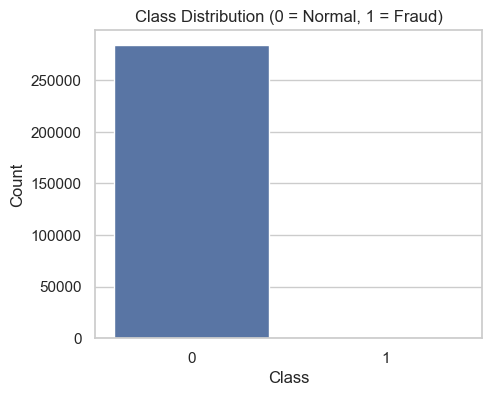

In [ ]:
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\nFraud percentage: {class_counts[1] / len(df) * 100:.4f}%")

plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Normal, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

Distribution of Amount and Time

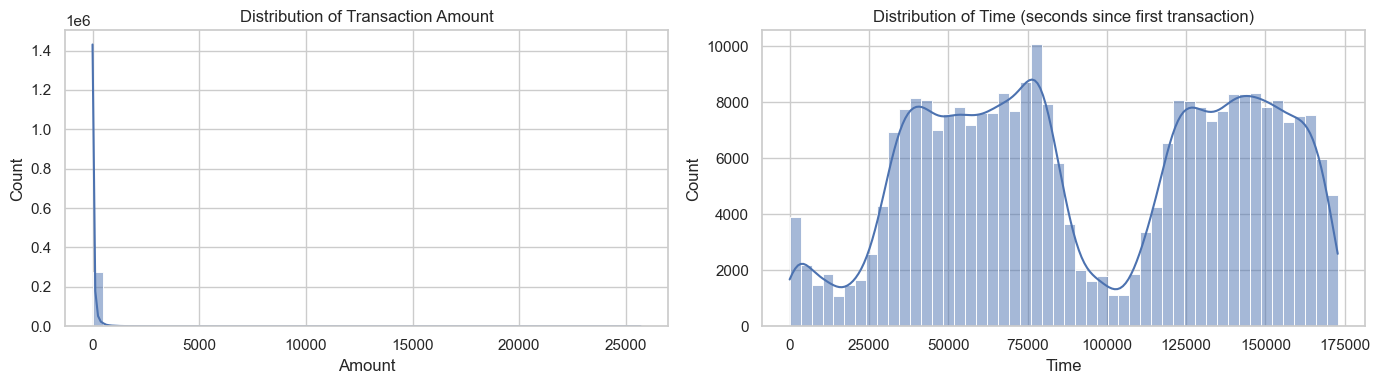

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))

sns.histplot(df['Amount'], bins=50, ax=ax[0], kde=True)
ax[0].set_title('Distribution of Transaction Amount')

sns.histplot(df['Time'], bins=50, ax=ax[1], kde=True)
ax[1].set_title('Distribution of Time (seconds since first transaction)')

plt.tight_layout()
plt.show()

Amount distribution: fraud vs normal

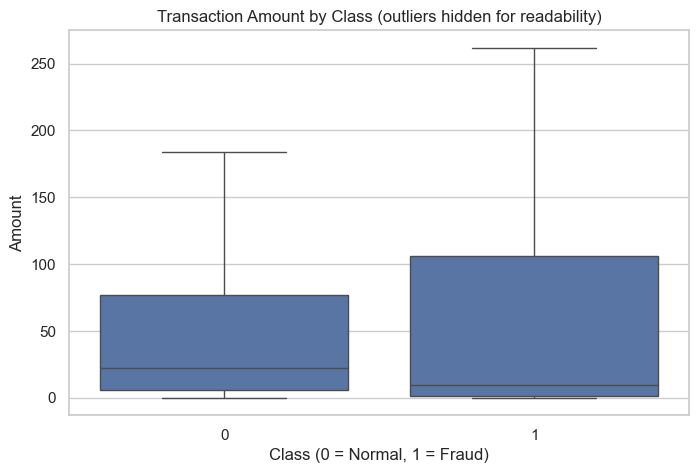

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df, showfliers=False)
plt.title('Transaction Amount by Class (outliers hidden for readability)')
plt.xlabel('Class (0 = Normal, 1 = Fraud)')
plt.ylabel('Amount')
plt.show()

Correlation heatmap

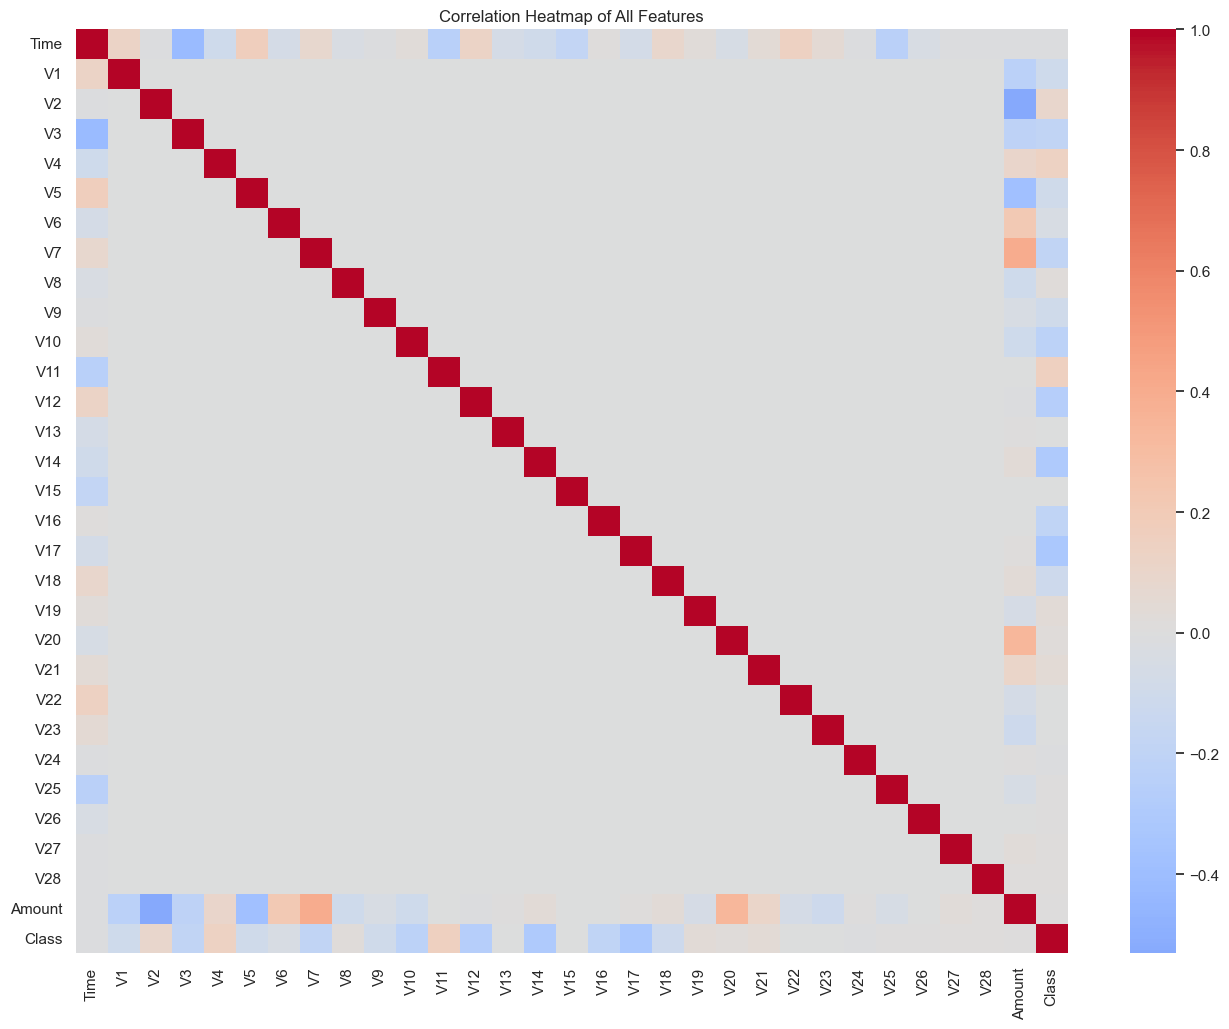

In [ ]:
plt.figure(figsize=(16,12))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of All Features')
plt.show()

Top features correlated with fraud

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64


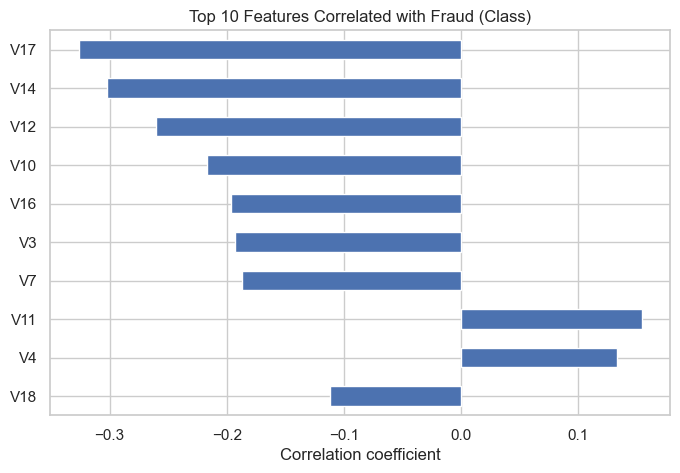

In [ ]:
fraud_corr = corr['Class'].drop('Class').sort_values(key=abs, ascending=False)
print(fraud_corr.head(10))

plt.figure(figsize=(8,5))
fraud_corr.head(10).plot(kind='barh')
plt.title('Top 10 Features Correlated with Fraud (Class)')
plt.xlabel('Correlation coefficient')
plt.gca().invert_yaxis()
plt.show()

Data Cleaning

In [ ]:
#Drop duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows")

Removed 1081 duplicate rows


Train / Validation / Test Split

In [ ]:
# Split the data
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

# First split: train+validation vs test (80/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Second split: train vs validation (60/20/20 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape, "Fraud rate:", y_train.mean())
print("Val:", X_val.shape, "Fraud rate:", y_val.mean())
print("Test:", X_test.shape, "Fraud rate:", y_test.mean())

Train: (170235, 30) Fraud rate: 0.0016682820806532147
Val: (56745, 30) Fraud rate: 0.0016565336152965019
Test: (56746, 30) Fraud rate: 0.0016741268107003137


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_features = ['Time', 'Amount']

X_train[scale_features] = scaler.fit_transform(
    X_train[scale_features]
)

X_val[scale_features] = scaler.transform(
    X_val[scale_features]
)

X_test[scale_features] = scaler.transform(
    X_test[scale_features]
)

X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
103118,-0.556304,-1.466684,0.437843,1.798819,-1.955137,-1.436692,0.141052,-1.339819,1.163623,-1.273979,...,-0.124413,0.585563,1.189609,-0.368531,-0.323312,0.410506,-0.108637,-0.307629,-0.095969,-0.321245
268849,1.441156,2.099619,-0.023369,-1.369803,0.224338,0.339848,-0.669249,0.224435,-0.315935,0.446580,...,-0.136091,-0.319857,-0.739342,0.237677,-0.748881,-0.181017,0.244591,-0.063086,-0.065425,-0.333418
2199,-1.961909,-1.960524,1.438062,-0.067457,-0.382996,0.369982,-0.113959,0.181212,0.504365,0.062941,...,0.029317,-0.448709,-0.847225,0.241987,-1.030383,0.234938,0.156216,0.338689,0.100345,-0.292801
177231,0.592616,1.838230,-0.641136,-0.425984,0.560873,-0.835237,0.005472,-1.102837,0.245831,1.666006,...,-0.030587,0.150565,0.399034,0.188064,0.483990,-0.557038,0.485454,0.003685,0.010003,-0.052021
227283,1.054002,0.751899,-2.034001,-1.388385,1.703266,-0.369474,0.535422,0.645324,-0.170321,0.656970,...,1.167378,-0.014687,-1.277865,-0.182382,0.156963,-0.475163,-1.138433,-0.064637,0.087829,2.275030


Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',  # compensates for class imbalance
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Validation — Tune Before Touching Test Set

              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56651
       Fraud       0.05      0.90      0.10        94

    accuracy                           0.97     56745
   macro avg       0.53      0.94      0.54     56745
weighted avg       1.00      0.97      0.99     56745



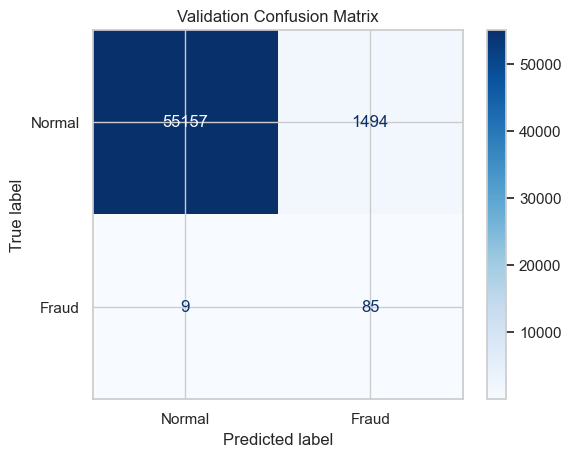

In [ ]:
#Evaluate on validation set
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_val_pred = model.predict(X_val)

print(classification_report(y_val, y_val_pred, target_names=['Normal', 'Fraud']))

cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Validation Confusion Matrix')
plt.show()

Explanation of metrics (this matters a lot for fraud detection):

Precision — of everything the model flagged as fraud, how many actually were fraud? Low precision = too many false alarms.

Recall — of all actual fraud cases, how many did the model catch? Low recall = missed fraud, which is usually the costlier mistake.

Accuracy is not a good metric here because of the imbalance — always look at precision/recall/F1 instead.

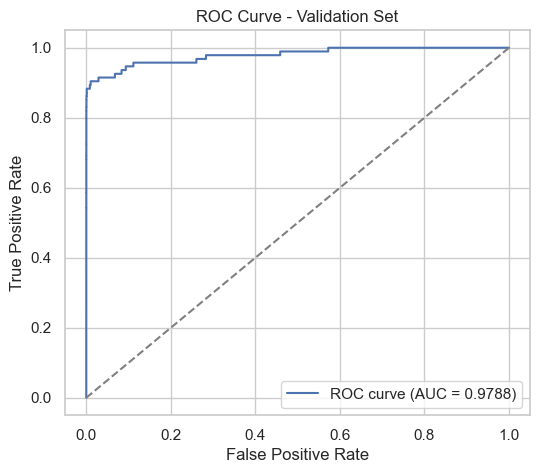

In [ ]:
#ROC curve and AUC on validation set
from sklearn.metrics import roc_curve, roc_auc_score

y_val_proba = model.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
auc = roc_auc_score(y_val, y_val_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Set')
plt.legend()
plt.show()

Explanation: The ROC curve shows the tradeoff between catching fraud (true positive rate) and false alarms (false positive rate) at different probability thresholds. AUC (Area Under Curve) summarizes this in one number — closer to 1.0 is better, 0.5 is random guessing.

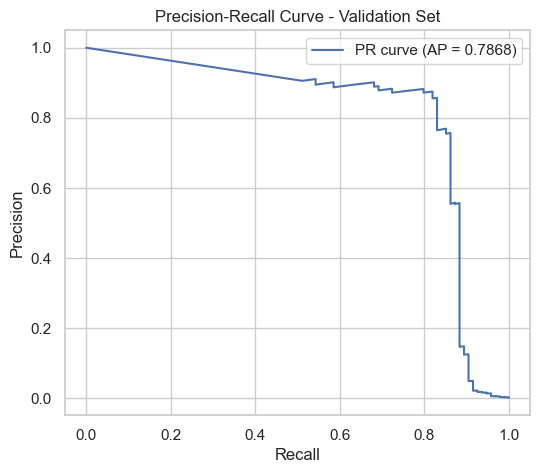

In [ ]:
#Precision-Recall curve (more informative than ROC for imbalanced data)
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_val, y_val_proba)
ap_score = average_precision_score(y_val, y_val_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR curve (AP = {ap_score:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Validation Set')
plt.legend()
plt.show()

Final Test Set Evaluation

              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746

Test ROC-AUC: 0.9645


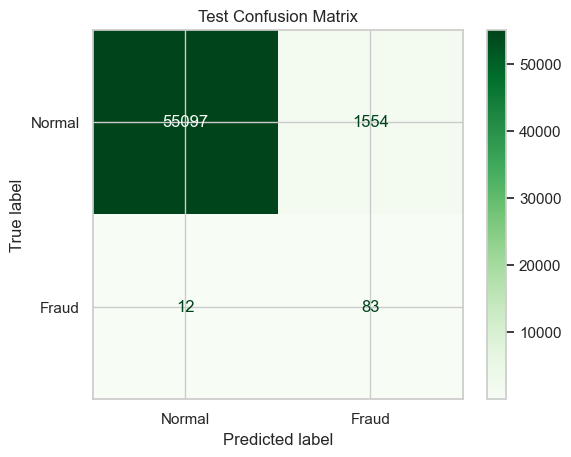

In [ ]:
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_test_pred, target_names=['Normal', 'Fraud']))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

cm_test = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Greens')
plt.title('Test Confusion Matrix')
plt.show()

   feature  coefficient
29  Amount     2.391513
14     V14    -1.660112
20     V20    -1.324978
10     V10    -1.197382
12     V12    -1.193447
27     V27    -1.017290
17     V17    -0.978502
1       V1     0.936507
5       V5     0.865511
4       V4     0.849904


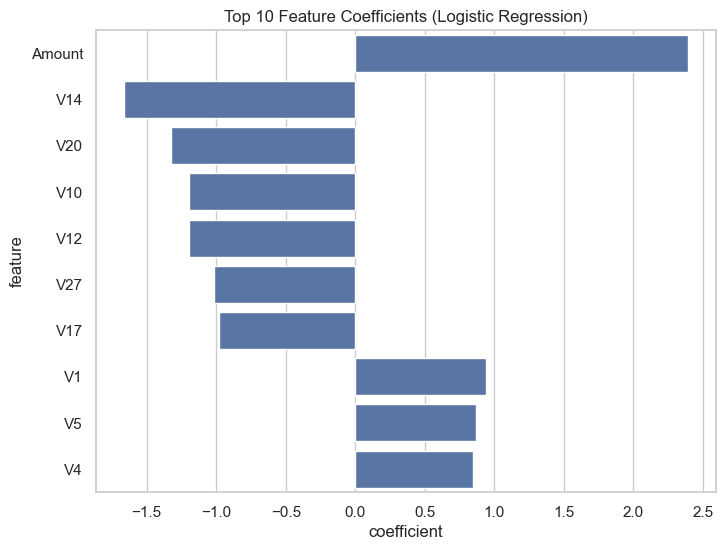

In [ ]:
#Which features push toward fraud?
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df.head(10))

plt.figure(figsize=(8,6))
sns.barplot(x='coefficient', y='feature', data=coef_df.head(10))
plt.title('Top 10 Feature Coefficients (Logistic Regression)')
plt.show()